# Adaptación rural para Perú sin pruebas de laboratorio

Este notebook conserva solo variables que podrían levantarse en una visita de campo:

- demografía e historial clínico,
- medidas antropométricas,
- bioimpedancia portátil.

Se excluyen pruebas de laboratorio para convertir el problema en uno de tamizaje y priorización de riesgo en contextos con acceso limitado a análisis clínicos.

/home/rosewt-dell/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Adaptación rural sin pruebas de laboratorio
Dataset cargado con dimensiones: (319, 39)
Conjunto de entrenamiento: (223, 25)
Conjunto de prueba: (96, 25)
Variables de entrada utilizadas: 25
Evaluando Logistic Regression...


Evaluando Random Forest...


Evaluando Gradient Boosting...


Evaluando XGBoost...


...


Resultados del benchmark:


,Modelo,Test Accuracy,Test AUC,Mejores Parámetros
0,XGBoost,0.750000,0.806858,"{'learning_rate': 0.1, 'n_estimators': 200}"
1,CatBoost,0.729167,0.799045,"{'iterations': 200, 'learning_rate': 0.1}"
2,Logistic Regression,0.718750,0.788628,{'C': 1}
3,Gradient Boosting,0.708333,0.801215,"{'learning_rate': 0.1, 'n_estimators': 200}"
4,Random Forest,0.708333,0.795139,"{'max_depth': 10, 'n_estimators': 100}"



Resumen comparativo final:


,Estrategia,Test Accuracy,Test AUC
0,Mejor benchmark (XGBoost),0.750000,0.806858
1,GB Optimizado (SMOTE + Optuna),0.770833,0.813802



Reporte de clasificación del modelo optimizado:
                  precision    recall  f1-score   support

        Sano (0)       0.74      0.83      0.78        48
Con cálculos (1)       0.81      0.71      0.76        48

        accuracy                           0.77        96
       macro avg       0.78      0.77      0.77        96
    weighted avg       0.78      0.77      0.77        96

Hiperparámetros fijados para replay determinista del mejor estudio Optuna original:
{'n_estimators': 692, 'learning_rate': 0.030187783433557297, 'max_depth': 8, 'min_samples_leaf': 16, 'subsample': 0.6342139062637353}


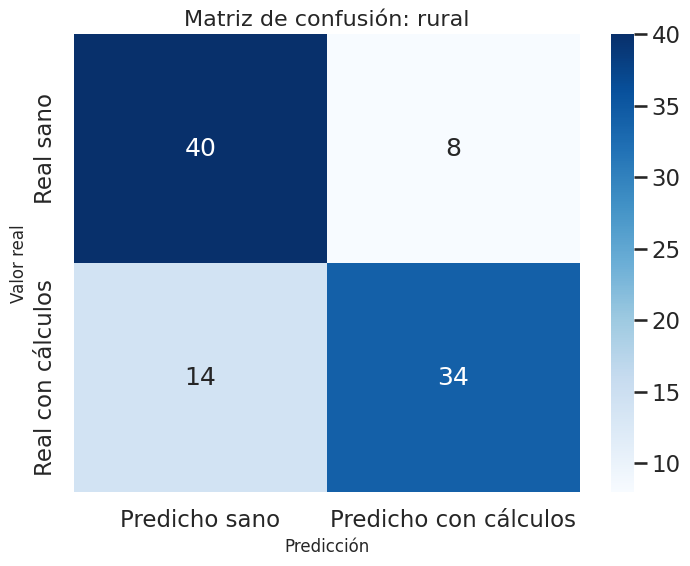

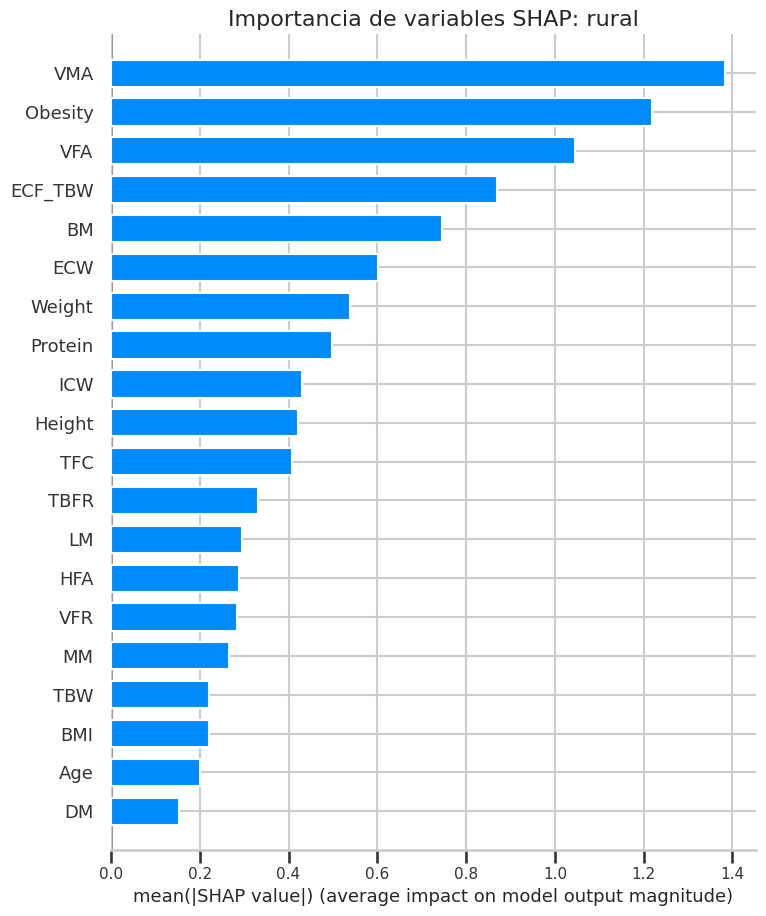

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(ROOT / "scripts"))

from portfolio_pipeline import LAB_EXCLUDED_FEATURES, run_rural_experiment

DATA_PATH = ROOT / "data" / "dataset-uci.xlsx"
FIGURES_DIR = ROOT / "figures"
REPORT_PATH = FIGURES_DIR / "rural_metrics.json"

results = run_rural_experiment(
    DATA_PATH,
    figures_dir=FIGURES_DIR,
    report_path=REPORT_PATH,
)

In [2]:
print("Variables excluidas por requerir laboratorio:")
for feature in LAB_EXCLUDED_FEATURES:
    print("-", feature)

Variables excluidas por requerir laboratorio:
- Glucose
- TC
- LDL
- HDL
- Triglyceride
- AST
- ALT
- ALP
- Creatinine
- GFR
- CRP
- HGB
- VitaminD
